# BestMetrics

Выбор до 5 лучших метрик для classifier и до 5 лучших метрик для detector по `best_balanced_accuracy`. Ноутбук не пересчитывает тяжелые карты: он читает готовые `all_metrics_quality.csv` и только нужные колонки из `all_metrics_rows.csv`.


In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "ClassifierDetectorExperiments":
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "ClassifierDetectorExperiments"))

import side_by_side_analysis as sbs
importlib.reload(sbs)

roots = sbs.resolve_roots(REPO_ROOT)
select_best_metrics = sbs.select_best_metrics
load_metric_rows_for_selected = sbs.load_metric_rows_for_selected
best_metric_confusion_table = sbs.best_metric_confusion_table
plot_best_metrics_quality = sbs.plot_best_metrics_quality
plot_best_metric_distributions_and_roc = sbs.plot_best_metric_distributions_and_roc
plot_best_metric_confusion = sbs.plot_best_metric_confusion

OUTPUT_DIR = roots.comparison_output
QUALITY_PATH = OUTPUT_DIR / "all_metrics_quality.csv"
ROWS_PATH = OUTPUT_DIR / "all_metrics_rows.csv"


In [2]:
quality = pd.read_csv(QUALITY_PATH, low_memory=False)
selected = select_best_metrics(quality, per_source=5)
rows = load_metric_rows_for_selected(ROWS_PATH, selected)
confusion = best_metric_confusion_table(selected, rows)

print("quality:", QUALITY_PATH)
print("rows:", ROWS_PATH)
print("selected metrics:", len(selected))
print("loaded rows shape:", rows.shape)

display_cols = [c for c in [
    "source", "experiment", "metric",
    "best_balanced_accuracy", "best_accuracy", "best_f1",
    "roc_auc", "roc_auc_effective", "best_threshold", "best_direction",
    "balanced_threshold", "balanced_direction",
] if c in selected.columns]
display(selected[display_cols])

conf_cols = [c for c in [
    "source", "experiment", "metric", "threshold_used", "direction_used",
    "tp", "tn", "fp", "fn", "n_eval",
] if c in confusion.columns]
display(confusion[conf_cols])


quality: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/all_metrics_quality.csv
rows: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/all_metrics_rows.csv
selected metrics: 10
loaded rows shape: (229119, 17)


,source,experiment,metric,best_balanced_accuracy,best_accuracy,best_f1,roc_auc,roc_auc_effective,best_threshold,best_direction,balanced_threshold,balanced_direction
0,classifier,spread_vs_precision,spread_delta_abs_mean,0.688276,0.743967,0.850070,0.732230,0.732230,0.062674,1,0.089690,1
1,classifier,spread_vs_precision,spread_delta_max,0.684508,0.747732,0.850203,0.743566,0.743566,0.505623,1,0.706521,1
2,classifier,spread_vs_precision,spread_delta_l2_rms,0.681676,0.747219,0.851214,0.740262,0.740262,0.126229,1,0.174206,1
3,classifier,psnr,psnr_top1_importance_sum,0.672146,0.746192,0.848658,0.703432,0.703432,2010.182214,-1,1894.416864,-1
4,classifier,psnr,psnr_top1_importance_mean,0.672146,0.746192,0.848658,0.703432,0.703432,8.008694,-1,7.547478,-1
5,detector,psnr,psnr_top7p9_importance_sum,0.658519,0.658519,0.726214,0.302952,0.697048,114129.224870,-1,112861.130905,-1
6,detector,psnr,psnr_top7p9_importance_mean,0.658519,0.658519,0.726214,0.302952,0.697048,7.054158,-1,6.975779,-1
7,detector,psnr,psnr_top7p3_importance_sum,0.657457,0.657457,0.726062,0.302561,0.697439,105342.484817,-1,104410.482671,-1
8,detector,psnr,psnr_top7p3_importance_mean,0.657457,0.657457,0.726062,0.302561,0.697439,7.046320,-1,6.983979,-1
9,detector,psnr,psnr_top7p7_importance_sum,0.656571,0.656571,0.726400,0.303364,0.696636,111410.138434,-1,110438.398055,-1


,source,experiment,metric,threshold_used,direction_used,tp,tn,fp,fn,n_eval
0,classifier,spread_vs_precision,spread_delta_abs_mean,0.089690,1,2803,1126,433,1481,5843
1,classifier,spread_vs_precision,spread_delta_max,0.706521,1,2386,1266,293,1898,5843
2,classifier,spread_vs_precision,spread_delta_l2_rms,0.174206,1,2675,1152,407,1609,5843
3,classifier,psnr,psnr_top1_importance_sum,1894.416864,-1,3055,984,575,1229,5843
4,classifier,psnr,psnr_top1_importance_mean,7.547478,-1,3055,984,575,1229,5843
5,detector,psnr,psnr_top7p9_importance_sum,112861.130905,-1,4242,3186,2106,1758,11292
6,detector,psnr,psnr_top7p9_importance_mean,6.975779,-1,4242,3186,2106,1758,11292
7,detector,psnr,psnr_top7p3_importance_sum,104410.482671,-1,4532,2942,2350,1468,11292
8,detector,psnr,psnr_top7p3_importance_mean,6.983979,-1,4532,2942,2350,1468,11292
9,detector,psnr,psnr_top7p7_importance_sum,110438.398055,-1,4574,2894,2398,1426,11292


## Quality Metrics

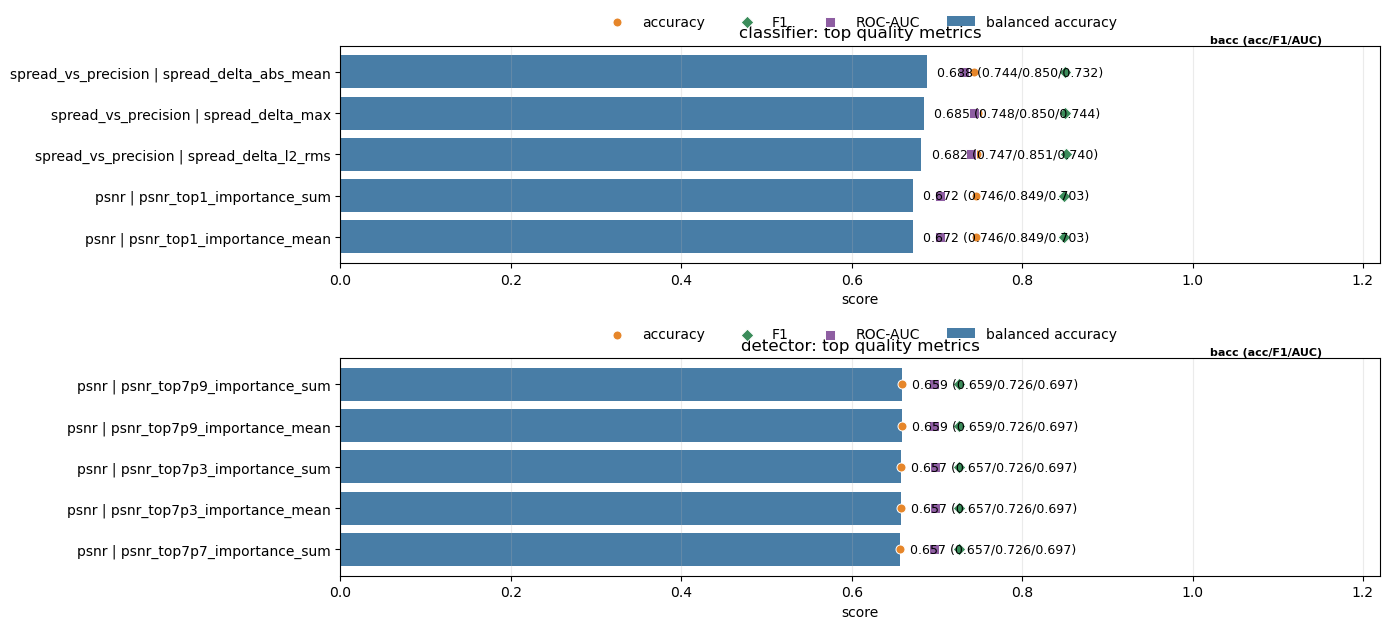

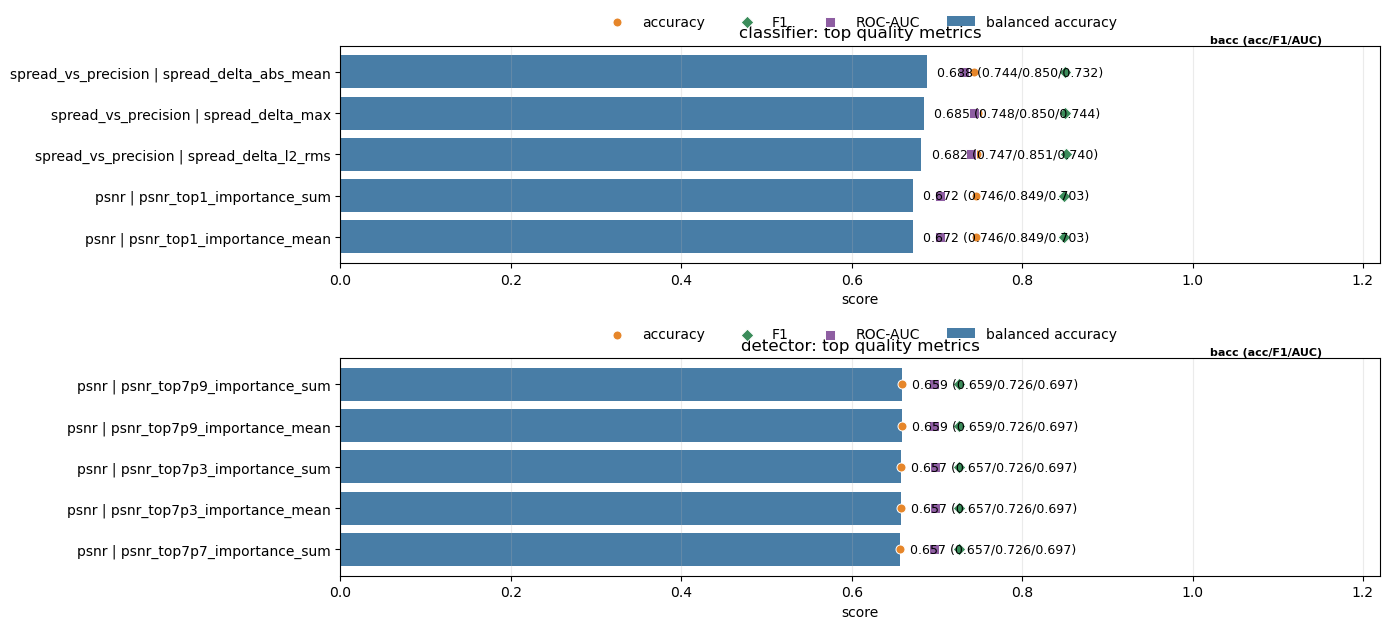

In [3]:
fig = plot_best_metrics_quality(selected)
fig.savefig(OUTPUT_DIR / "best_metrics_quality.png", dpi=160, bbox_inches="tight")
fig


## Classifier Metric Distributions And ROC

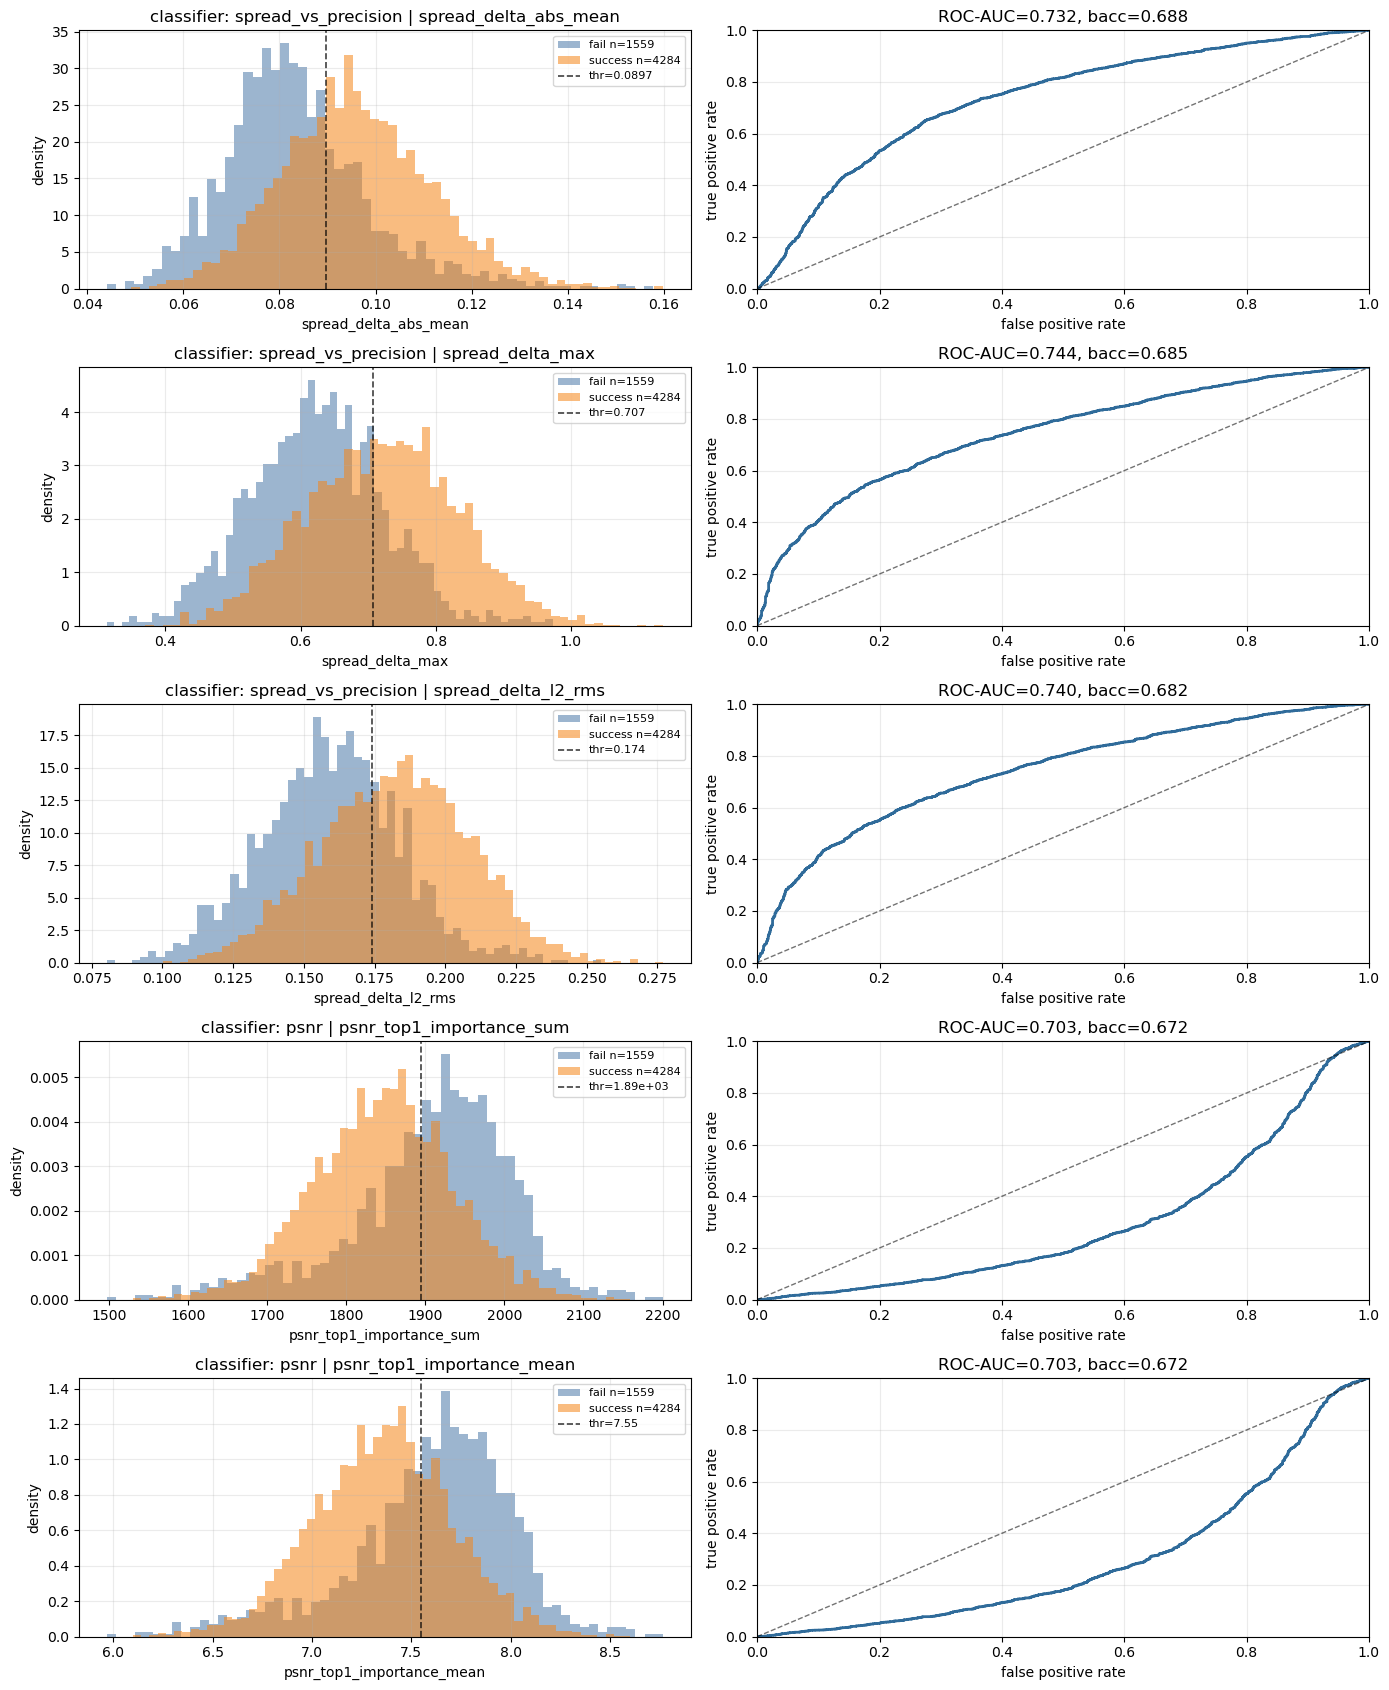

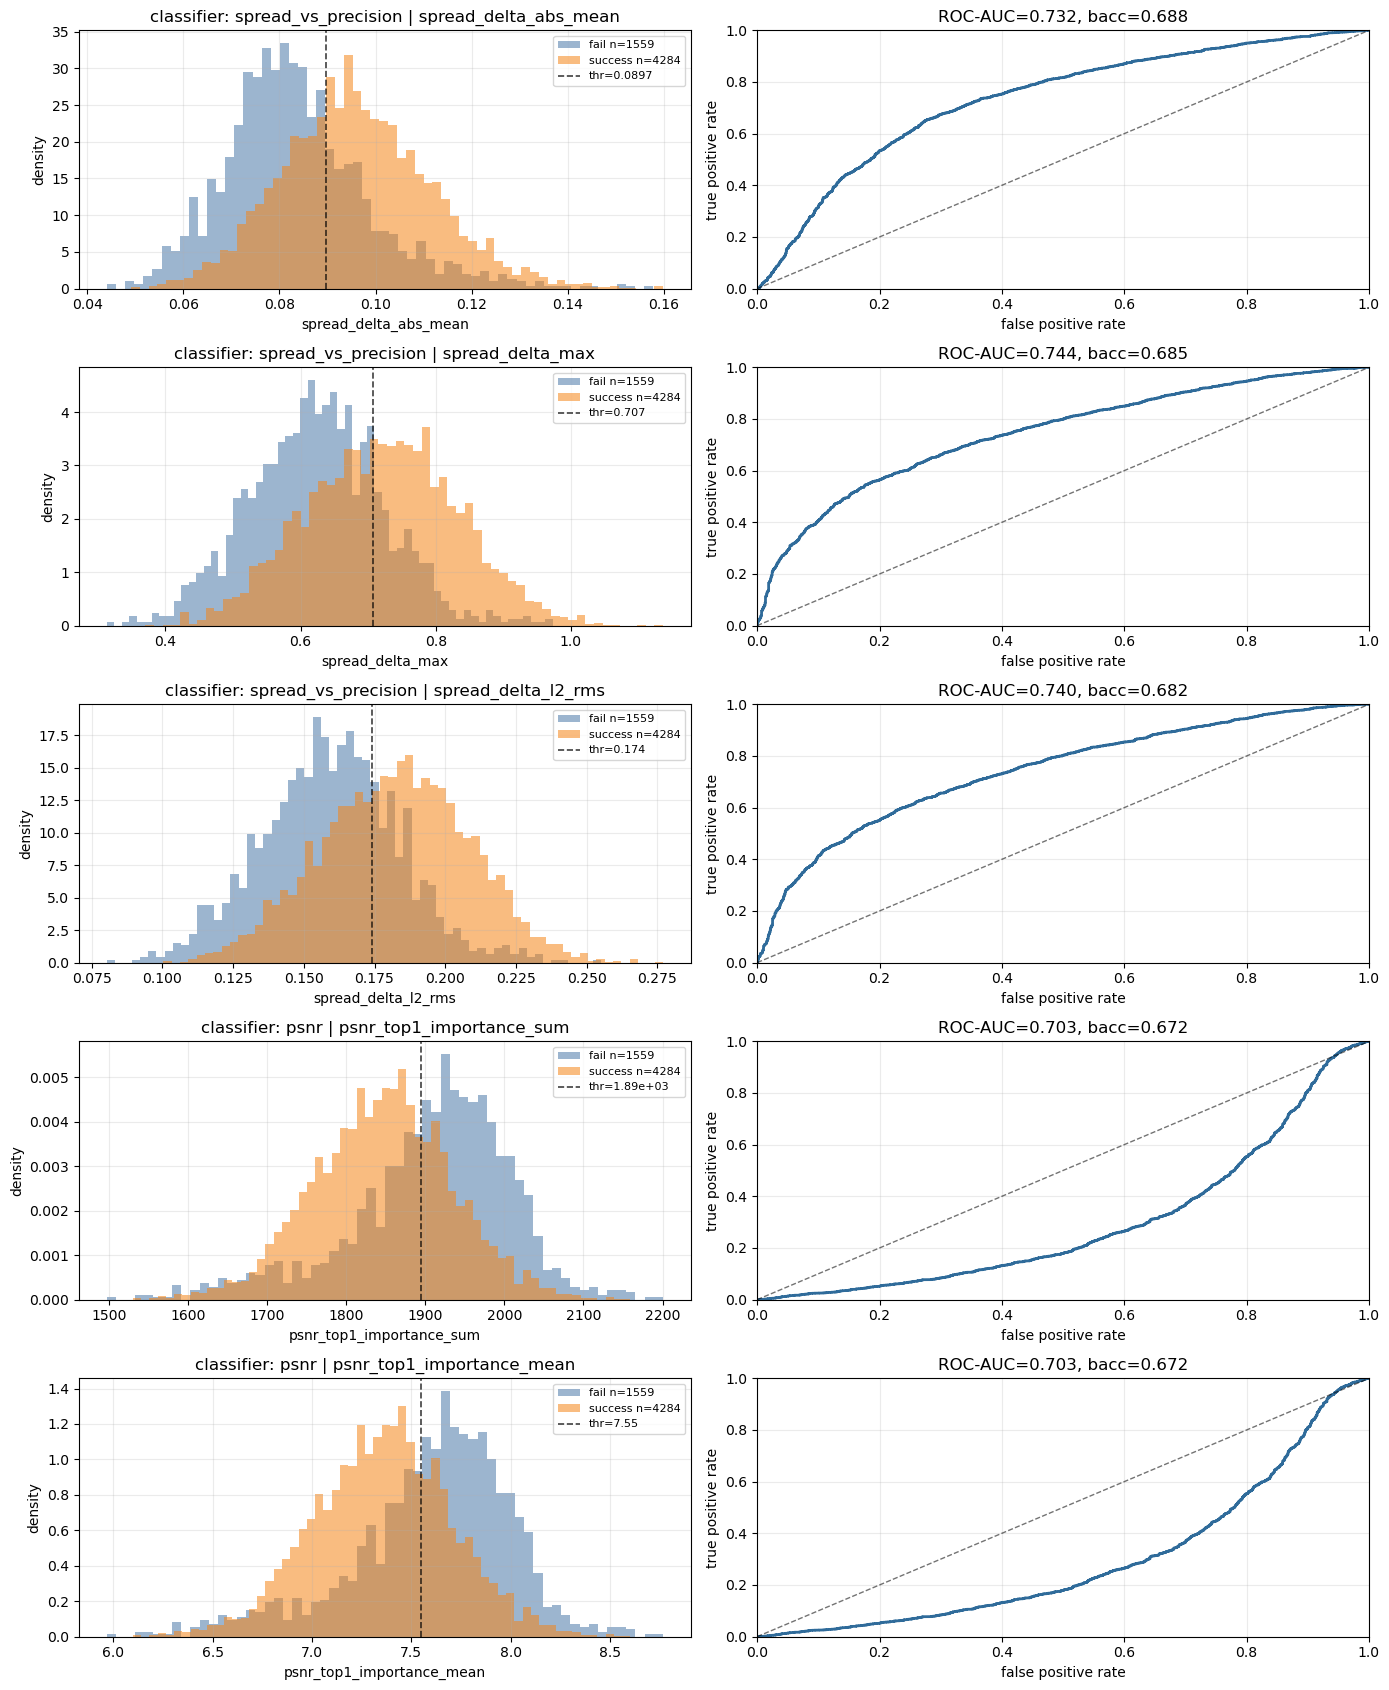

In [4]:
fig = plot_best_metric_distributions_and_roc(selected, rows, source="classifier")
fig.savefig(OUTPUT_DIR / "best_metrics_classifier_distribution_roc.png", dpi=160, bbox_inches="tight")
fig


## Detector Metric Distributions And ROC

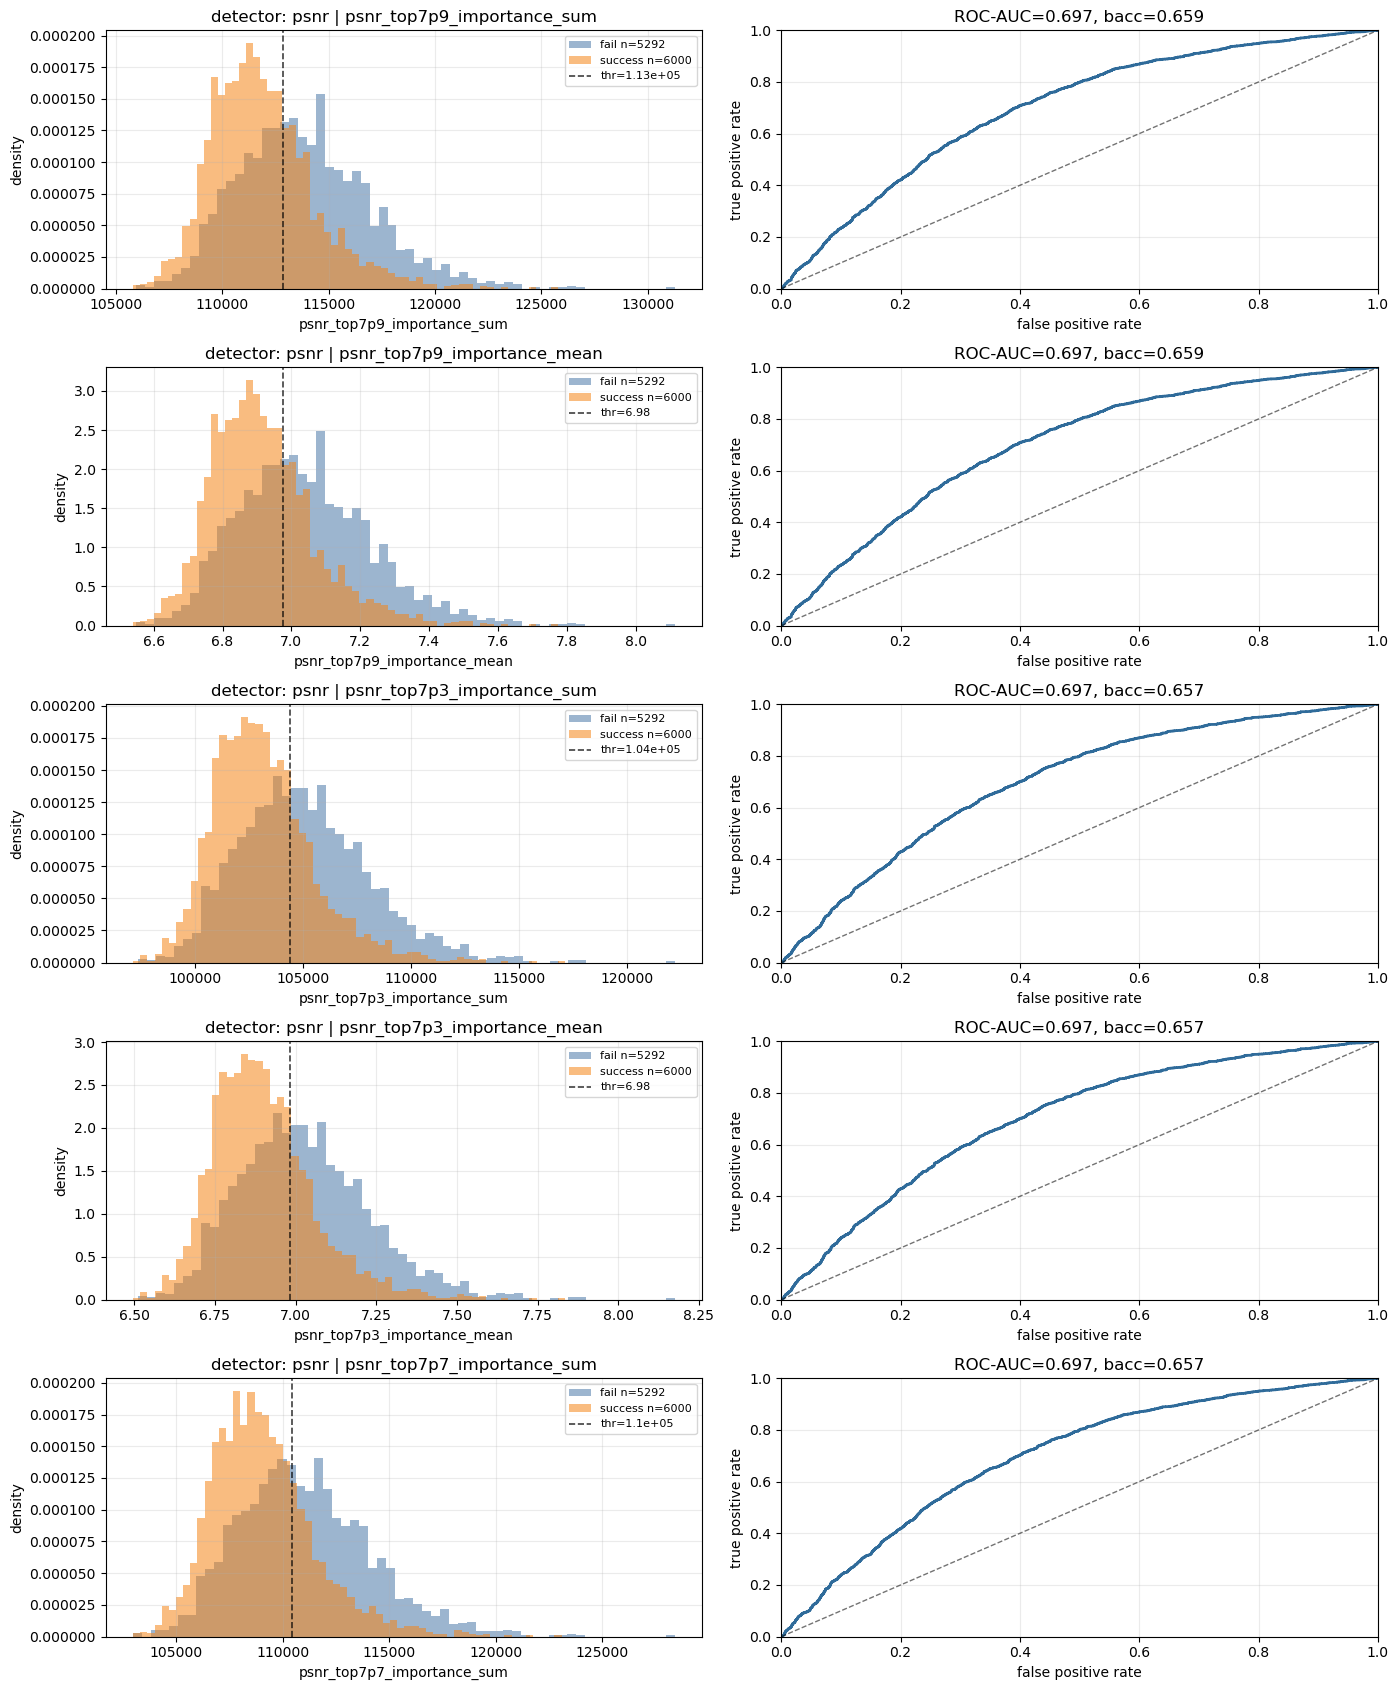

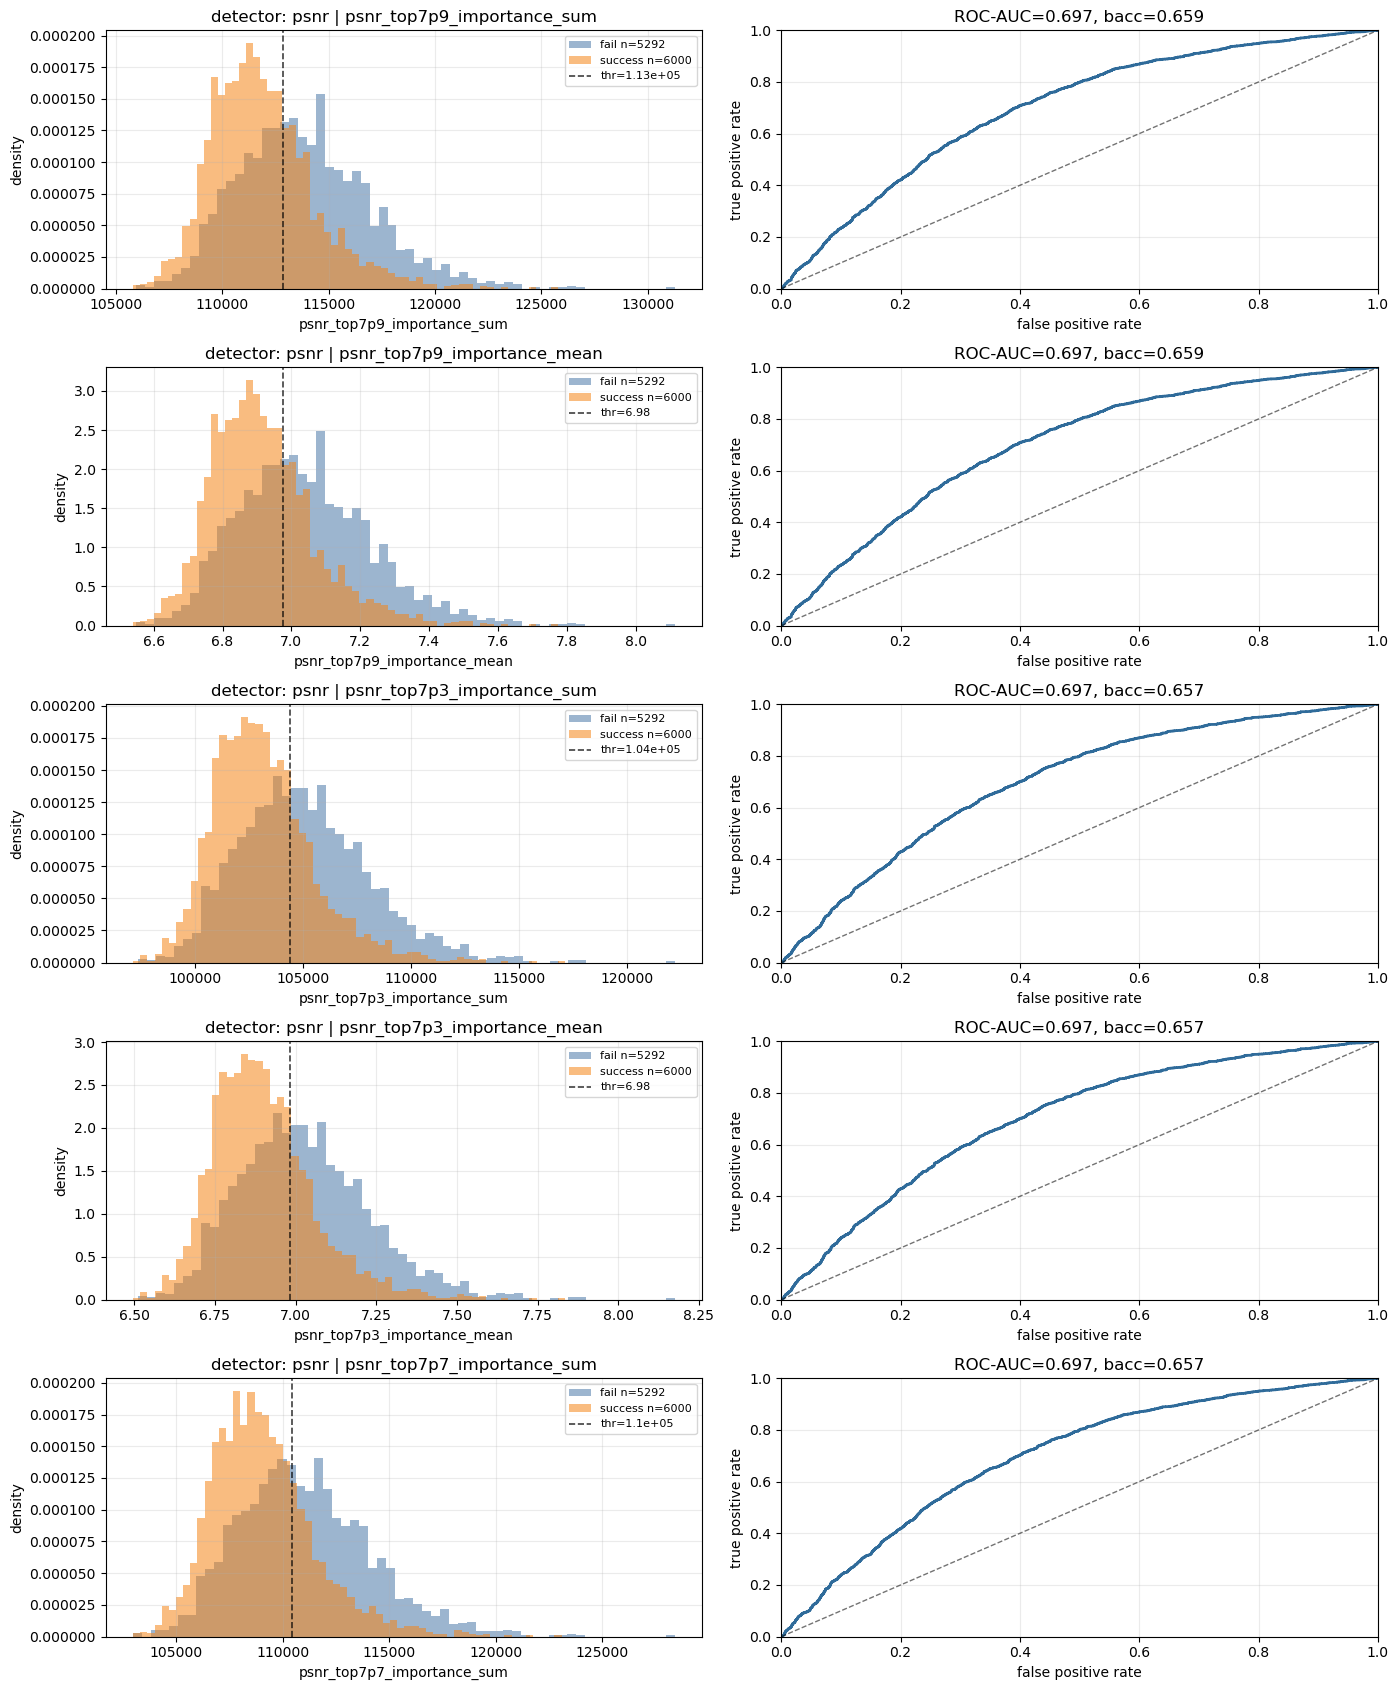

In [5]:
fig = plot_best_metric_distributions_and_roc(selected, rows, source="detector")
fig.savefig(OUTPUT_DIR / "best_metrics_detector_distribution_roc.png", dpi=160, bbox_inches="tight")
fig


## TP/TN/FP/FN

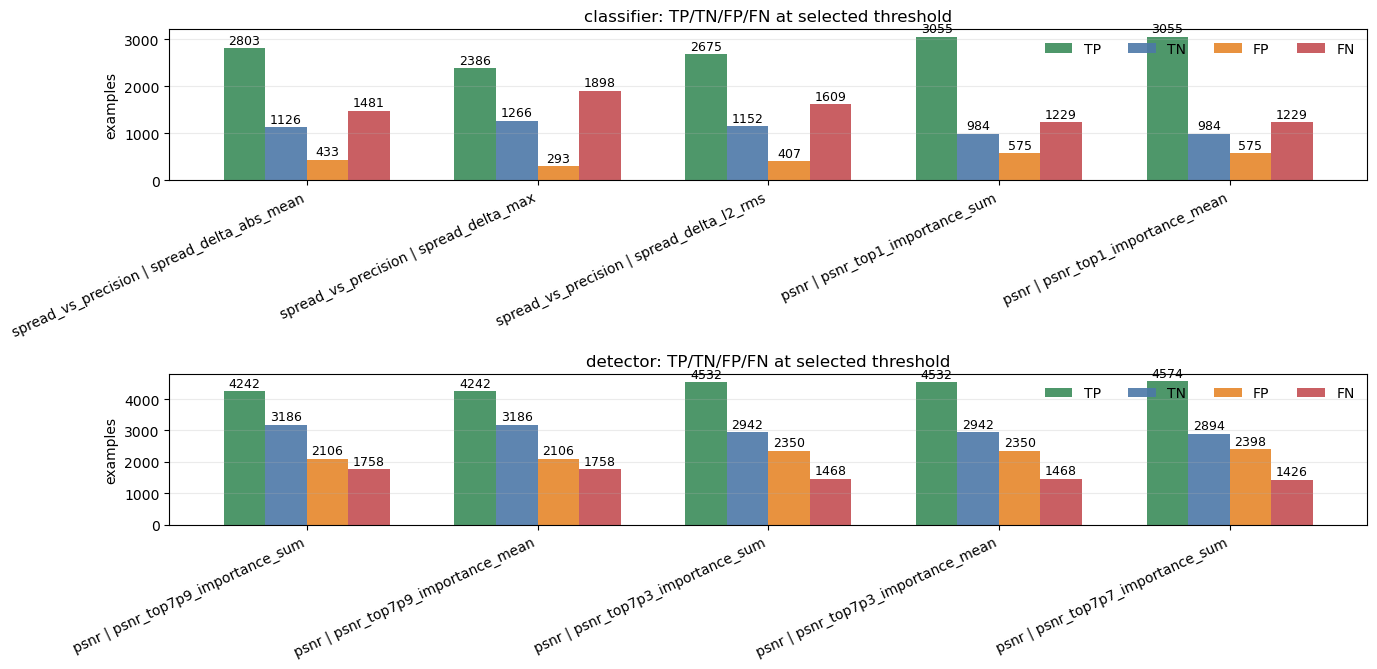

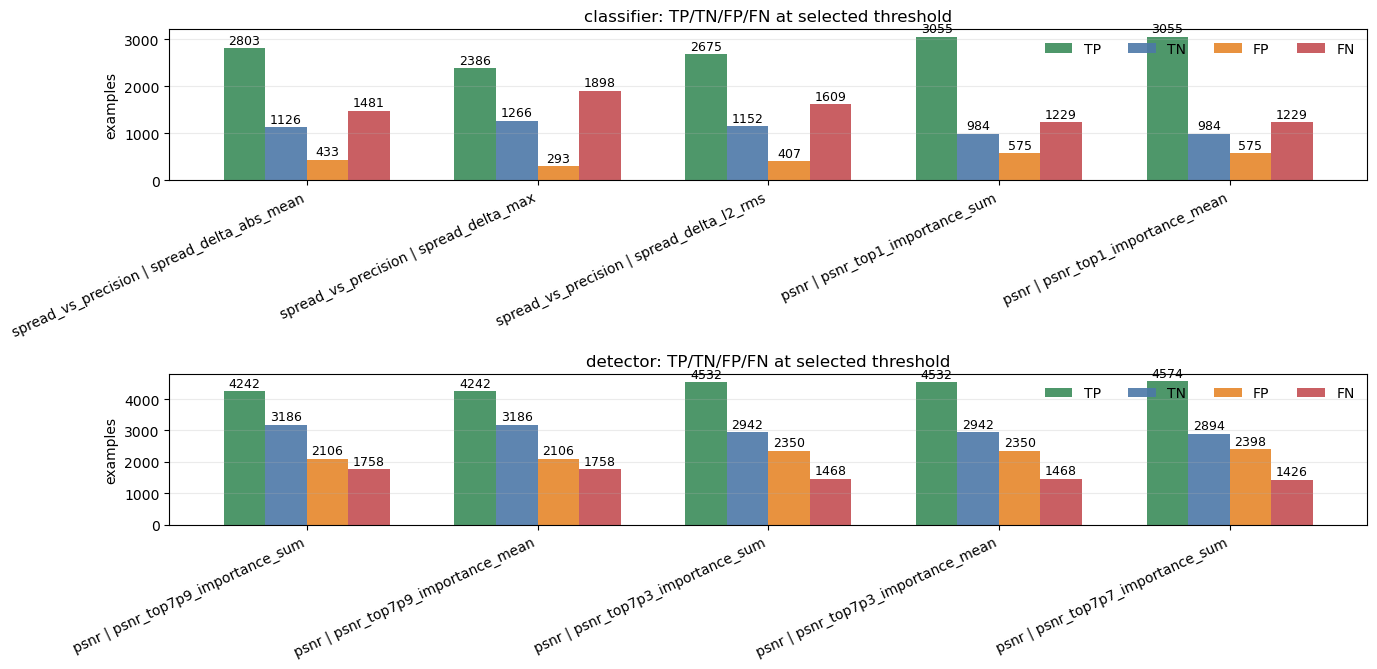

In [6]:
fig = plot_best_metric_confusion(confusion)
fig.savefig(OUTPUT_DIR / "best_metrics_confusion.png", dpi=160, bbox_inches="tight")
fig


In [7]:
selected.to_csv(OUTPUT_DIR / "best_metrics_selected.csv", index=False)
confusion.to_csv(OUTPUT_DIR / "best_metrics_confusion.csv", index=False)
print("saved:")
print(OUTPUT_DIR / "best_metrics_selected.csv")
print(OUTPUT_DIR / "best_metrics_confusion.csv")
print(OUTPUT_DIR / "best_metrics_quality.png")
print(OUTPUT_DIR / "best_metrics_classifier_distribution_roc.png")
print(OUTPUT_DIR / "best_metrics_detector_distribution_roc.png")
print(OUTPUT_DIR / "best_metrics_confusion.png")


saved:
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/best_metrics_selected.csv
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/best_metrics_confusion.csv
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/best_metrics_quality.png
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/best_metrics_classifier_distribution_roc.png
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/best_metrics_detector_distribution_roc.png
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/best_metrics_confusion.png
